In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib
import matplotlib.pyplot as plt
from umap import UMAP
import sklearn
import seaborn as sns
from COSMOS import cosmos
from COSMOS.pyWNN import pyWNN 
import h5py
import warnings
warnings.filterwarnings('ignore')
random_seed = 20

/home/dbj/anaconda3/envs/cosmos/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
adata_omics1=sc.read_h5ad('/home/dbj/mouse/SpatialGlue/Mouse_Brain/adata_RNA.h5ad')
adata_omics2=sc.read_h5ad('/home/dbj/mouse/SpatialGlue/Mouse_Brain/adata_peaks_normalized.h5ad')
adata_omics1.var_names_make_unique()
adata_omics2.var_names_make_unique()
sc.pp.filter_genes(adata_omics1, min_cells=10)
sc.pp.highly_variable_genes(adata_omics1, flavor="seurat_v3", n_top_genes=3000)
adata_omics1 = adata_omics1[:, adata_omics1.var['highly_variable']].copy()  # Filter for highly variable genes
# Convert to CSC format

# Preprocess adata2 (ADT) - optionally apply the same transformation
sc.pp.highly_variable_genes(adata_omics2, flavor="seurat_v3", n_top_genes=3000)
adata_omics2 = adata_omics2[:, adata_omics2.var['highly_variable']].copy()

In [4]:
cosmos_comb = cosmos.Cosmos(adata1=adata_omics1,adata2=adata_omics2)
cosmos_comb.preprocessing_data(n_neighbors = 16)
cosmos_comb.train(spatial_regularization_strength=0.01, z_dim=50, 
         lr=1e-3, wnn_epoch = 500, total_epoch=1000, max_patience_bef=10, max_patience_aft=30, min_stop=200, 
         random_seed=random_seed, gpu=0, regularization_acceleration=True, edge_subset_sz=1000000)
weights = cosmos_comb.weights
df_embedding = pd.DataFrame(cosmos_comb.embedding)

Epoch 1/1000, Loss: 1.4268145561218262
Epoch 11/1000, Loss: 1.380427598953247
Epoch 21/1000, Loss: 1.334881067276001
Epoch 31/1000, Loss: 1.0494166612625122
Epoch 41/1000, Loss: 0.7023147940635681
Epoch 51/1000, Loss: 0.4354831278324127
Epoch 61/1000, Loss: 0.2649015188217163
Epoch 71/1000, Loss: 0.14298886060714722
Epoch 81/1000, Loss: 0.0728779062628746
Epoch 91/1000, Loss: 0.03978448361158371
Epoch 101/1000, Loss: 0.02358945831656456
Epoch 111/1000, Loss: 0.01653352752327919
Epoch 121/1000, Loss: 0.012298250570893288
Epoch 131/1000, Loss: 0.010023636743426323
Epoch 141/1000, Loss: 0.008994976058602333
Epoch 151/1000, Loss: 0.007285962346941233
Epoch 161/1000, Loss: 0.010038048028945923
Computing KNN distance matrices using default Scanpy implementation
Computing modality weights
Computing weighted distances for union of 200 nearest neighbors between modalities
0 out of 9215 0.00 seconds elapsed
2000 out of 9215 5.77 seconds elapsed
4000 out of 9215 11.47 seconds elapsed
6000 out of 

In [11]:
adata_new = adata_omics1.copy()
embedding_adata = sc.AnnData(df_embedding)
sc.pp.neighbors(embedding_adata, n_neighbors=50, use_rep='X')

# Manualy setting resolution for clustering
res = 1.48
sc.tl.louvain(embedding_adata, resolution=res)
adata_new.obs['COSMOS'] = list(embedding_adata.obs["louvain"].cat.codes)
adata_new.obs["COSMOS"]=adata_new.obs["COSMOS"].astype('category')

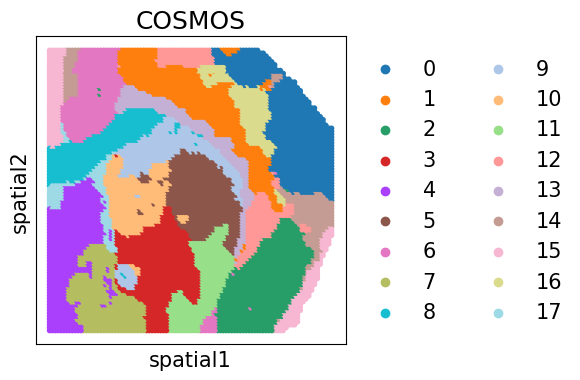

In [12]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (4,4)
plt.rcParams['font.size'] = 15

fig, ax = plt.subplots()
sc.pl.embedding(adata_new,basis='spatial',color='COSMOS',size=70,ax=ax)

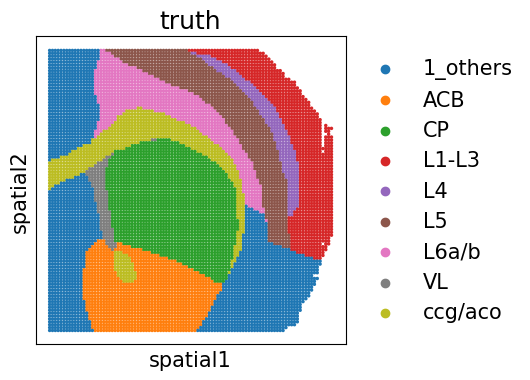

In [13]:
adata=sc.read_h5ad('/home/dbj/mouse/spatialglue_alldata/Dataset7_Mouse_Brain_ATAC/3d-OT.h5ad')
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (4,4)
plt.rcParams['font.size'] = 15

fig, ax = plt.subplots()
sc.pl.embedding(adata,basis='spatial',color='truth',size=25,ax=ax)

In [17]:
adata_new=adata_new[adata_new.obs_names.isin(adata.obs_names)]

In [18]:
import numpy as np
from sklearn.metrics import (homogeneity_score,mutual_info_score,v_measure_score,adjusted_mutual_info_score,normalized_mutual_info_score,adjusted_rand_score
)

true_labels = np.array(adata.obs['truth'])
cluster_labels = np.array(adata_new.obs['COSMOS'])

homogeneity = homogeneity_score(true_labels, cluster_labels)
mutual_info = mutual_info_score(true_labels, cluster_labels)
v_measure = v_measure_score(true_labels, cluster_labels)
ami = adjusted_mutual_info_score(true_labels, cluster_labels)
nmi = normalized_mutual_info_score(true_labels, cluster_labels)
ari = adjusted_rand_score(true_labels, cluster_labels)

print("Homogeneity:", homogeneity)
print("Mutual Information:", mutual_info)
print("V-Measure:", v_measure)
print("AMI:", ami)
print("NMI:", nmi)
print("ARI:", ari)

Homogeneity: 0.6797164947446387
Mutual Information: 1.3579506831501218
V-Measure: 0.564849893742355
AMI: 0.5634951493362592
NMI: 0.564849893742355
ARI: 0.30823575437875844
